# Importing packages

In [1]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns

Running SCIMAP  2.1.3


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
preprocessed_dir = Path(config['preprocessed_dir'])

# make a roi list of directories in preprocessed_dir that are not .DS_Store
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

In [3]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()
adata.obs.run = adata.obs.run.astype("category")
adata.obs.patient_ID = adata.obs.patient_ID.astype("category")
#normalize adata.X by dividing the values of each row by the row's Cell 3D volume from obs
adata.raw = adata.copy()
adata.X = adata.X / adata.obs["Cell 3D Volume"].values[:, None]
#do variance stabilizing transformation via square root
adata.X = np.sqrt(adata.X)


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/merge.py:1280: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/merge.py:1280: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/

In [4]:
#correct for batch effects
sc.pp.scale(adata)
adata.X = adata.X.astype(np.float32).copy()

In [5]:
#sort adata by patient ID
adata = adata[adata.obs["patient_ID"].sort_values().index]

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



TypeError: circles() got multiple values for argument 'x'

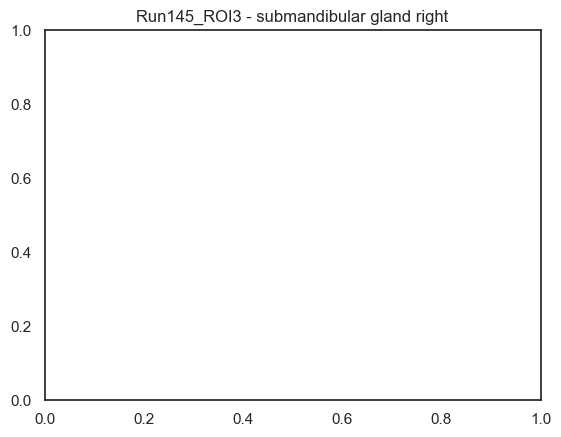

In [ ]:
#Make a scatterplot based on the coordinates of the cells for each sample with axes

for exp in adata.obs.exp_name.unique():
    adata_select = adata[adata.obs.exp_name == exp]
    site = adata_select.obs.site.unique()[0]
    sc.pl.scatter(adata_select, x = "Cell Center X", y = "Cell Center Y", color="cell_type", ax=plt.gca(), size=10, palette="tab20", title=f'{exp} - {site}', groups=["MDSCs", "Tumor_cells", "Granulocytes", "M2_macrophages"])

array([[ 3.3132246 , -0.51263195,  0.17989731, ...,  0.11091295,
        -0.0828962 , -0.9628267 ],
       [-0.5092667 , -0.4955368 , -0.33235615, ...,  0.5255633 ,
        -0.2132729 , -1.1268334 ],
       [ 0.17412388,  0.7811289 ,  1.2474686 , ...,  1.7997968 ,
         2.062931  , -0.41584197],
       ...,
       [-0.75030637, -0.5413992 , -0.86127406, ..., -0.4546853 ,
         0.00770002,  0.0565362 ],
       [-0.76597214, -0.28848752, -0.7486445 , ..., -0.24320485,
         0.3145048 ,  0.102261  ],
       [-0.8280288 , -0.6278097 , -0.97115815, ..., -0.585777  ,
        -0.14678957, -0.03402897]], dtype=float32)

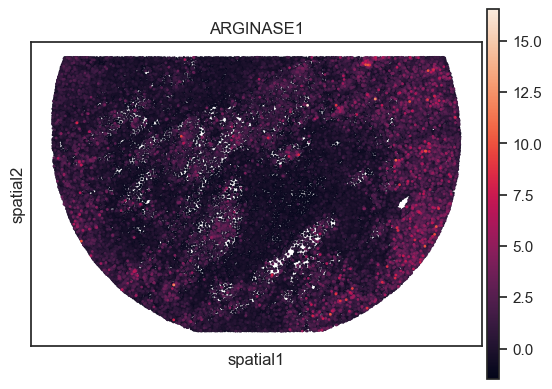

In [ ]:
adata_select = adata[adata.obs.exp_name == "Run141_ROI4"]
site = adata_select.obs.site.unique()[0]
sc.pl.spatial(adata_select, color="ARGINASE1", spot_size=100, layer="X")

## How interactions are similar across all sampless

## Spatial distances

In [6]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                               phenotype='cell_type', 
                               label='2D_distance',
                               imageid="exp_name")

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run145_ROI3
Processing Image: Run141_ROI19
Processing Image: Run141_ROI1
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run145_ROI1
Processing Image: Run141_ROI4
Processing Image: Run141_ROI23
Processing Image: Run141_ROI3
Processing Image: Run141_ROI14


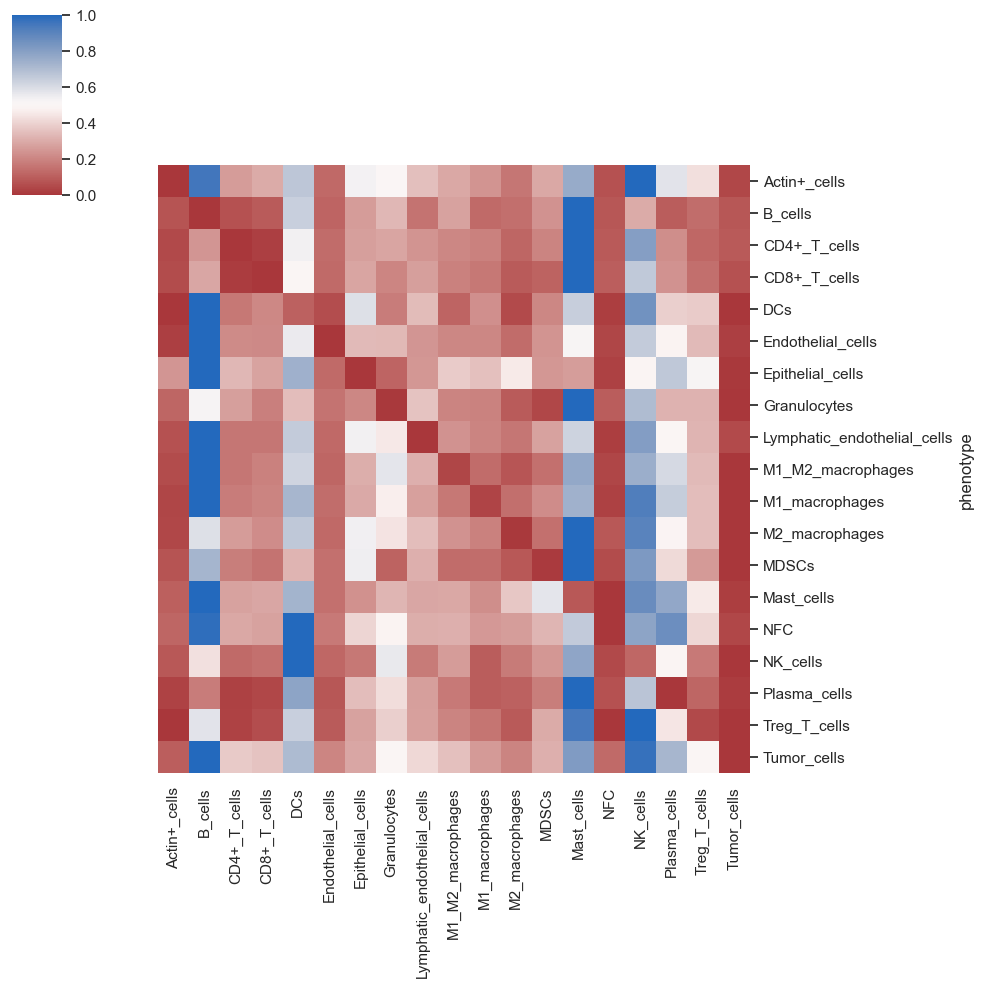

In [7]:
sm.pl.spatial_distance(adata, phenotype='cell_type', imageid='exp_name', spatial_distance="2D_distance", method="heatmap")

## Spatial LDA

In [8]:
sm.tl.spatial_lda(adata, 
                  x_coordinate='Cell Center X', 
                  y_coordinate='Cell Center Y',
                  phenotype="cell_type", 
                  method='knn', 
                  knn=15, 
                  imageid='exp_name', 
                  num_motifs=10, 
                  label='spatial_lda')

Processing: ['Run141_ROI11']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI16']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI7']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run145_ROI3']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI19']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI1']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI8']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI17']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI15']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run145_ROI1']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI4']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI23']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_R

AnnData object with n_obs × n_vars = 309273 × 61
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [9]:
sm.tl.spatial_cluster(adata, df_name='spatial_lda', method='kmeans', k=8, label='spatial_lda_kmeans')

Kmeans clustering


AnnData object with n_obs × n_vars = 309273 × 61
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

TypeError: object of type 'list_reverseiterator' has no len()

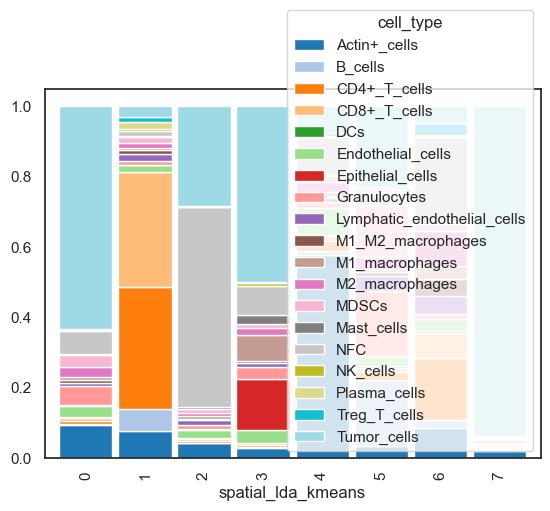

In [13]:
sm.pl.stacked_barplot(adata, x_axis='spatial_lda_kmeans', y_axis='cell_type')

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_9568/2237259650.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



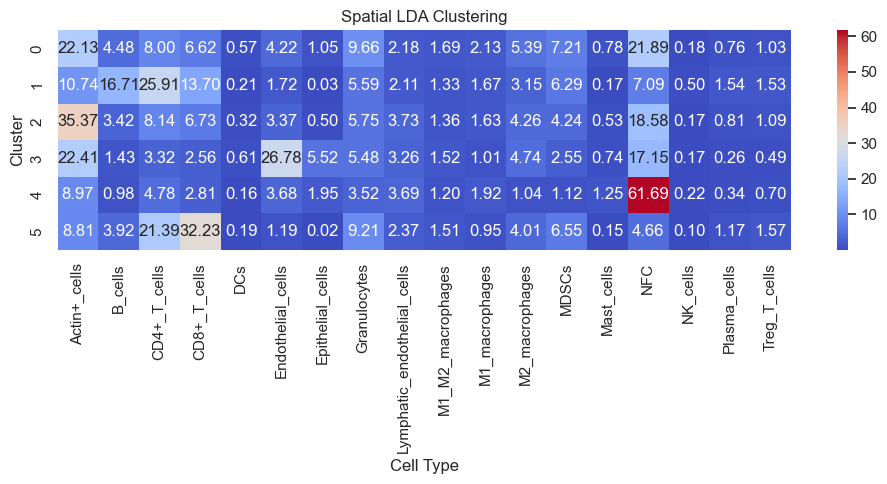

In [26]:
counts = adata.obs.groupby(["spatial_lda_kmeans", "cell_type"]).size().unstack().fillna(0)
counts = counts.drop(columns="Tumor_cells")
counts = counts.div(counts.sum(axis=1), axis=0).mul(100)
plt.figure(figsize=(10, 5))
sns.heatmap(counts, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Spatial LDA Clustering")
plt.xlabel("Cell Type") 
plt.ylabel("Cluster")
plt.tight_layout()

In [9]:
sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_type",
                         method='delaunay',
                         permutation=300,
                         imageid='exp_name',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['Run145_ROI3']
Categories (1, object): ['Run145_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run145_ROI1']
Categories (1, object): ['Run145_ROI1']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI1']
Categories (1, object): ['Run141_ROI1']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI4']
Categories (1, object): ['Run141_ROI4']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI3']
Categories (1, object): ['Run141_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI15']
Categories (1, object): ['Run141_ROI15']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI14']
Categories (1, object): ['Run141_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI11']
Categories (1, object): ['Run141_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the perm

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_interaction.py:399: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



AnnData object with n_obs × n_vars = 309273 × 61
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

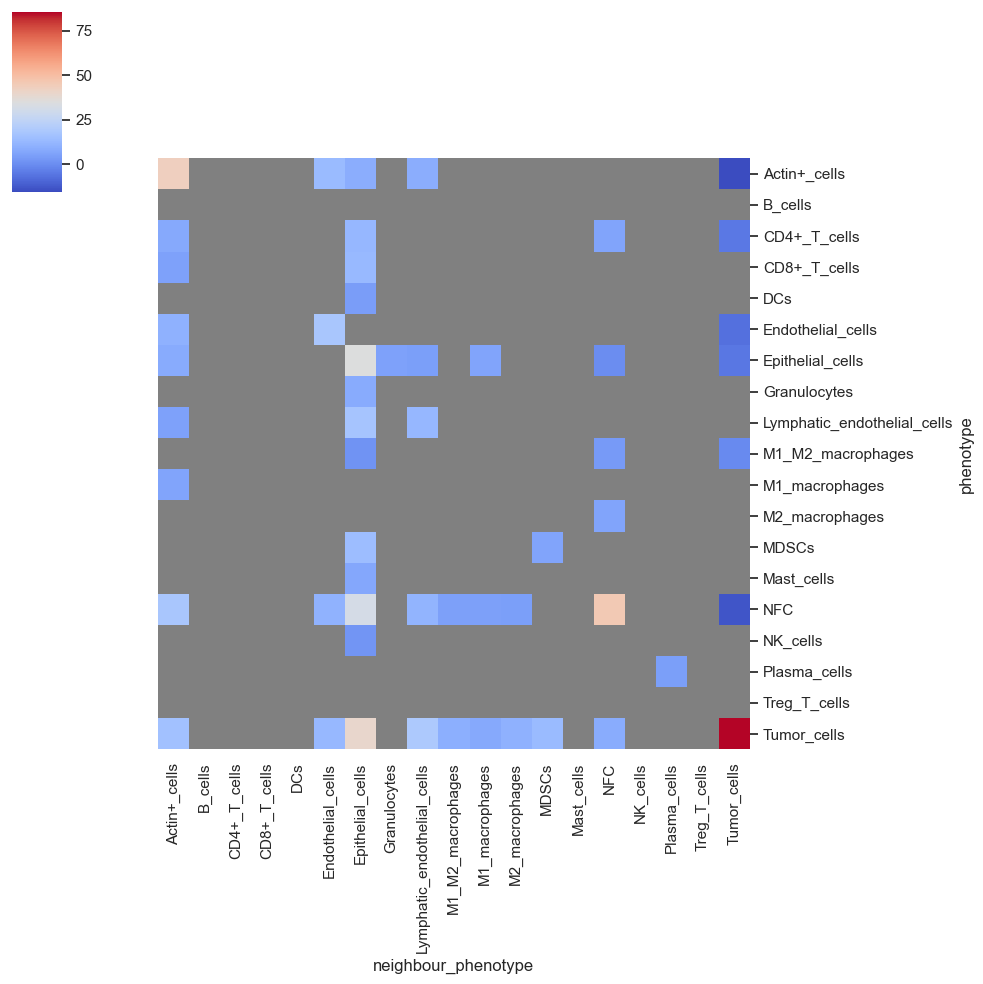

In [11]:
sm.pl.spatial_interaction(adata, p_val=0.05, cmap='coolwarm', spatial_interaction="scimap_delaunay_conditional_zscore")

In [23]:
heatmap_data = adata.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
heatmap_data.columns = heatmap_data.columns.str.replace('zscore_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "patient_ID").loc[:,["exp_name", "patient_ID"]].drop_duplicates().reset_index(drop=True)
heatmap_data = heatmap_data[ordered_columns["exp_name"]]
heatmap_data.columns = ordered_columns["patient_ID"].values
heatmap_data = heatmap_data.filter(like="CD4+_T_cells-", axis=0)

In [24]:
heatmap_data

,NMC_1,NMC_1,NMC_2,NMC_9,NMC_9,NMC_13,NMC_13,NMC_14,NMC_14,NMC_15,NMC_15,NMC_16,NMC_16,NMC_21
CD4+_T_cells-Actin+_cells,7.869357,0.810975,3.752380,27.225131,44.641051,3.414709,4.072795,16.677901,18.885898,5.670463,6.914907,10.817012,29.124023,7.301676
CD4+_T_cells-B_cells,-0.803860,0.693254,2.661656,33.001950,62.575787,-1.099168,-1.593811,0.286772,1.029776,-1.776825,0.412298,-0.307529,45.751613,-0.236960
CD4+_T_cells-CD4+_T_cells,0.220879,1.485404,8.824567,89.618758,156.601391,-0.313961,3.051832,27.301012,79.825844,28.456588,1.847165,17.773457,48.581245,1.312065
CD4+_T_cells-CD8+_T_cells,0.109423,-0.249288,8.618369,30.284133,58.751887,-0.229033,-0.313961,4.122693,22.114192,14.446135,0.712236,9.258753,39.853570,-0.561014
CD4+_T_cells-DCs,-0.338906,-0.229033,1.225863,8.301792,13.097107,-0.100336,2.441168,2.622936,-0.224021,NaN,NaN,0.688005,8.157528,0.608663
CD4+_T_cells-Endothelial_cells,-0.447142,8.928034,6.697666,13.621172,30.492918,1.701946,2.241694,11.454412,18.334420,5.511865,3.913903,9.364000,17.849147,3.690223
CD4+_T_cells-Epithelial_cells,NaN,NaN,54.921751,NaN,NaN,NaN,NaN,NaN,NaN,4.685434,6.129965,NaN,NaN,NaN
CD4+_T_cells-Granulocytes,-0.252224,-0.462450,15.529145,-7.328547,-1.924117,-0.100336,8.391234,1.833924,14.289401,9.190176,4.832787,2.352589,17.605299,2.786135
CD4+_T_cells-Lymphatic_endothelial_cells,0.420684,2.552984,5.922089,26.813629,24.062498,5.330484,-0.759617,0.216441,30.424527,6.762660,0.126244,5.549111,31.146451,1.548517
CD4+_T_cells-M1_M2_macrophages,3.178352,3.004541,0.657955,12.266337,16.862485,3.575211,1.955994,-0.240721,6.069323,3.724824,0.826581,4.493200,7.857985,0.898109


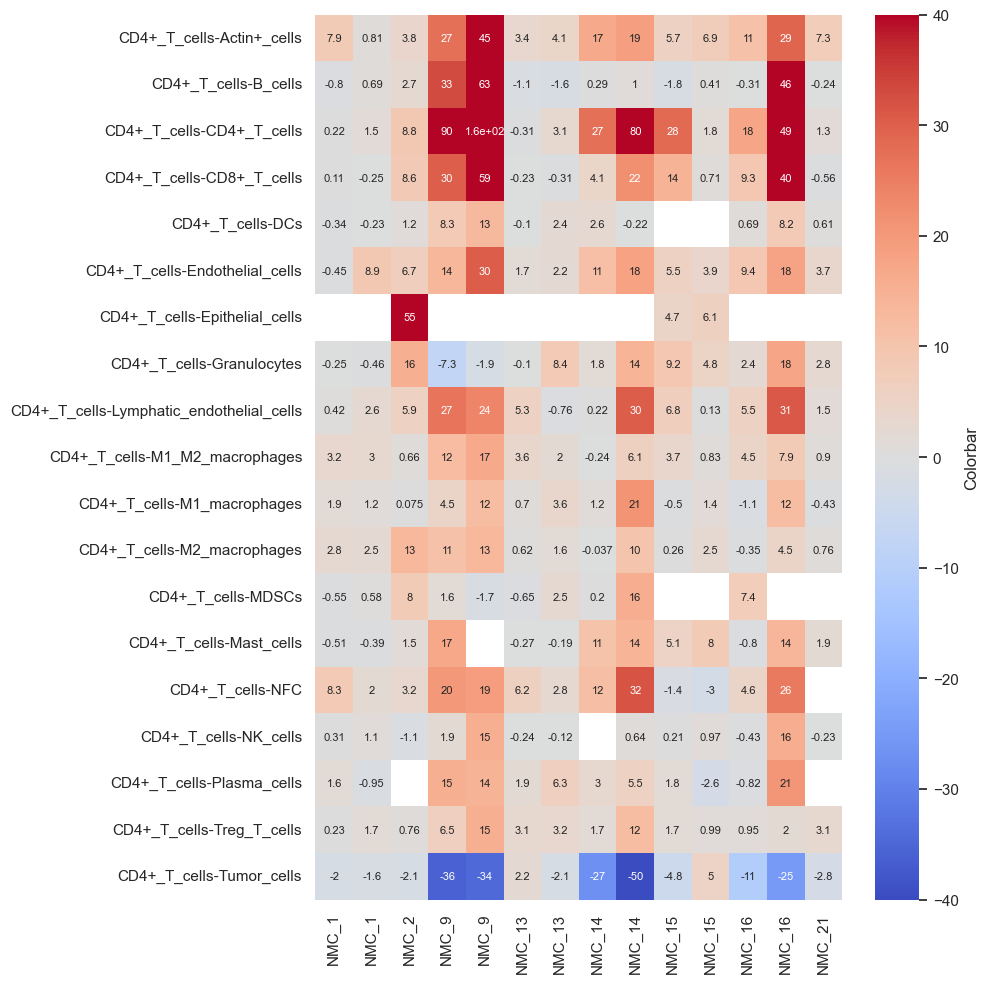

In [25]:
plt.figure(figsize=(10, 10))

# Plot the heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Colorbar'},  # Optional, for better colorbar label
    vmin=-40,
    vmax=40
)

# Rotate row labels for better readability
plt.yticks(rotation=0)  # You can adjust this angle as needed (0 for horizontal)

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

In [23]:
ordered_columns

,exp_name,outcome_group
0,Run141_ROI11,long_term survival
1,Run141_ROI8,long_term survival
2,Run141_ROI19,long_term survival
3,Run141_ROI17,long_term survival
4,Run145_ROI1,long_term survival
5,Run145_ROI3,long_term survival
6,Run141_ROI4,short_term survival
7,Run141_ROI23,short_term survival
8,Run141_ROI3,short_term survival
9,Run141_ROI14,short_term survival


In [24]:
adata.obs.loc[:, ["outcome_group", "exp_name", "site"]].drop_duplicates()

,outcome_group,exp_name,site
0,long_term survival,Run141_ROI11,extrahepatic bile ducts
0-1,short_term survival,Run141_ROI16,lung
0-2,short_term survival,Run141_ROI7,lung
0-3,long_term survival,Run141_ROI19,"cervical, A. carotis int. right"
0-4,short_term survival,Run141_ROI1,lung hilus right
0-5,long_term survival,Run141_ROI8,extrahepatic bile ducts
0-6,long_term survival,Run141_ROI17,"cervical, A. carotis int. right"
0-7,short_term survival,Run141_ROI15,"sample: metastasis left tigh, skin \nprimary s..."
0-8,short_term survival,Run141_ROI4,central left lung
0-9,short_term survival,Run141_ROI23,"intrathoracic, right bronchus"


In [12]:
cell_colors = {
    "Tumor_cells": "#FF6347",  # Tomato red
    "Actin+_cells": "grey",  # Steel blue
    "CD8+_T_cells": "#32CD32",  # Lime green
    "M1_macrophages": "#FFD700",  # Gold
    "Treg_T_cells": "#8A2BE2",  # Blue violet
    "M2_macrophages": "#00FA9A",  # Medium spring green
    "DCs": "#FF4500",  # Orange red
    "Endothelial_cells": "#2E8B57",  # Sea green
    "CD4+_T_cells": "#9932CC",  # Dark orchid
    "Mast_cells": "#DAA520",  # Goldenrod
    "Lymphatic_endothelial_cells": "#A52A2A",  # Brown
    "Granulocytes": "#C71585",  # Medium violet red
    "M1_M2_macrophages": "#D2691E",  # Chocolate
    "Plasma_cells": "#8B0000",  # Dark red
    "B_cells": "#4169E1",  # Royal blue
    "MDSCs": "#B22222",  # Firebrick
    "Epithelial_cells": "#228B22",  # Forest green
    "NK_cells": "#FF1493"  # Deep pink
}

In [56]:
adata.obs.outcome_group

0           long_term survival
1           long_term survival
2           long_term survival
3           long_term survival
4           long_term survival
                  ...         
16649-6    short_term survival
16650-6    short_term survival
16651-6    short_term survival
16652-6    short_term survival
16653-6    short_term survival
Name: outcome_group, Length: 179902, dtype: category
Categories (2, object): ['long_term survival', 'short_term survival']

In [13]:
long_term = adata.obs[adata.obs["outcome_group"] == "long_term survival"].exp_name.unique().astype(str)
short_term = adata.obs[adata.obs["outcome_group"] == "short_term survival"].exp_name.unique().astype(str)

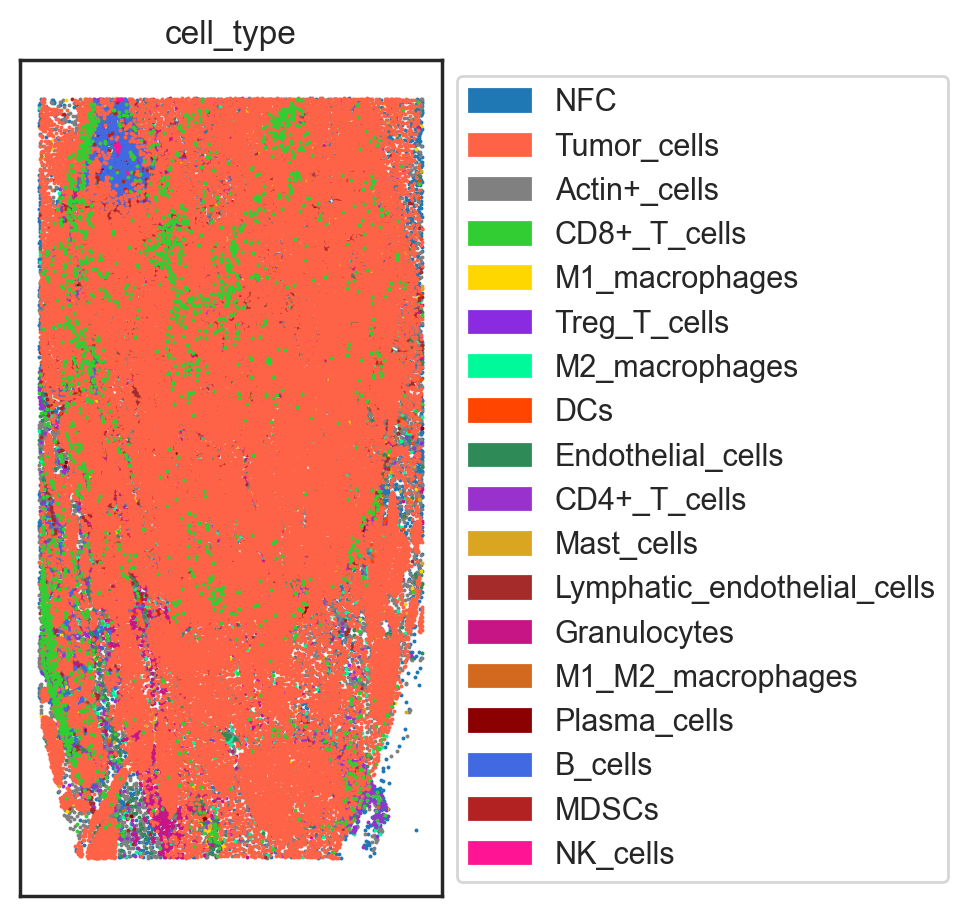

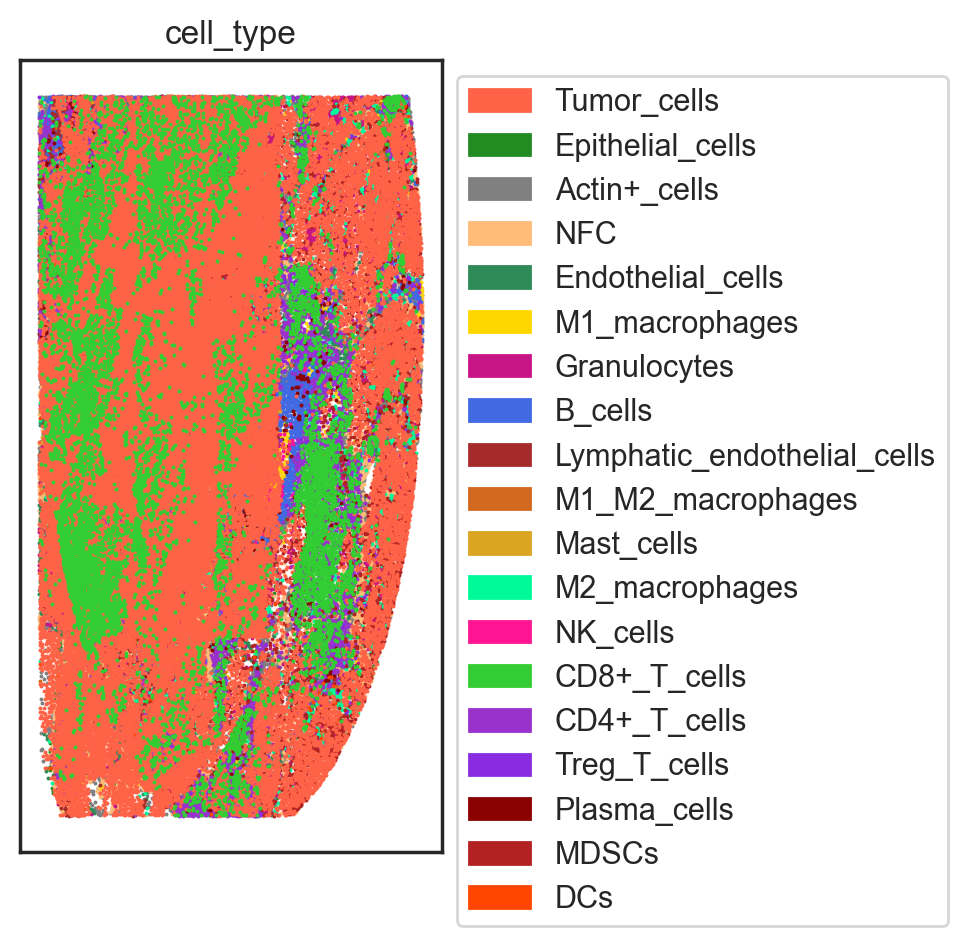

In [15]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)


In [96]:
ordered_columns

['zscore_Run141_ROI11',
 'zscore_Run141_ROI19',
 'zscore_Run141_ROI8',
 'zscore_Run141_ROI17',
 'zscore_Run141_ROI16',
 'zscore_Run141_ROI7',
 'zscore_Run141_ROI15',
 'zscore_Run141_ROI23']

TypeError: object of type 'list_reverseiterator' has no len()

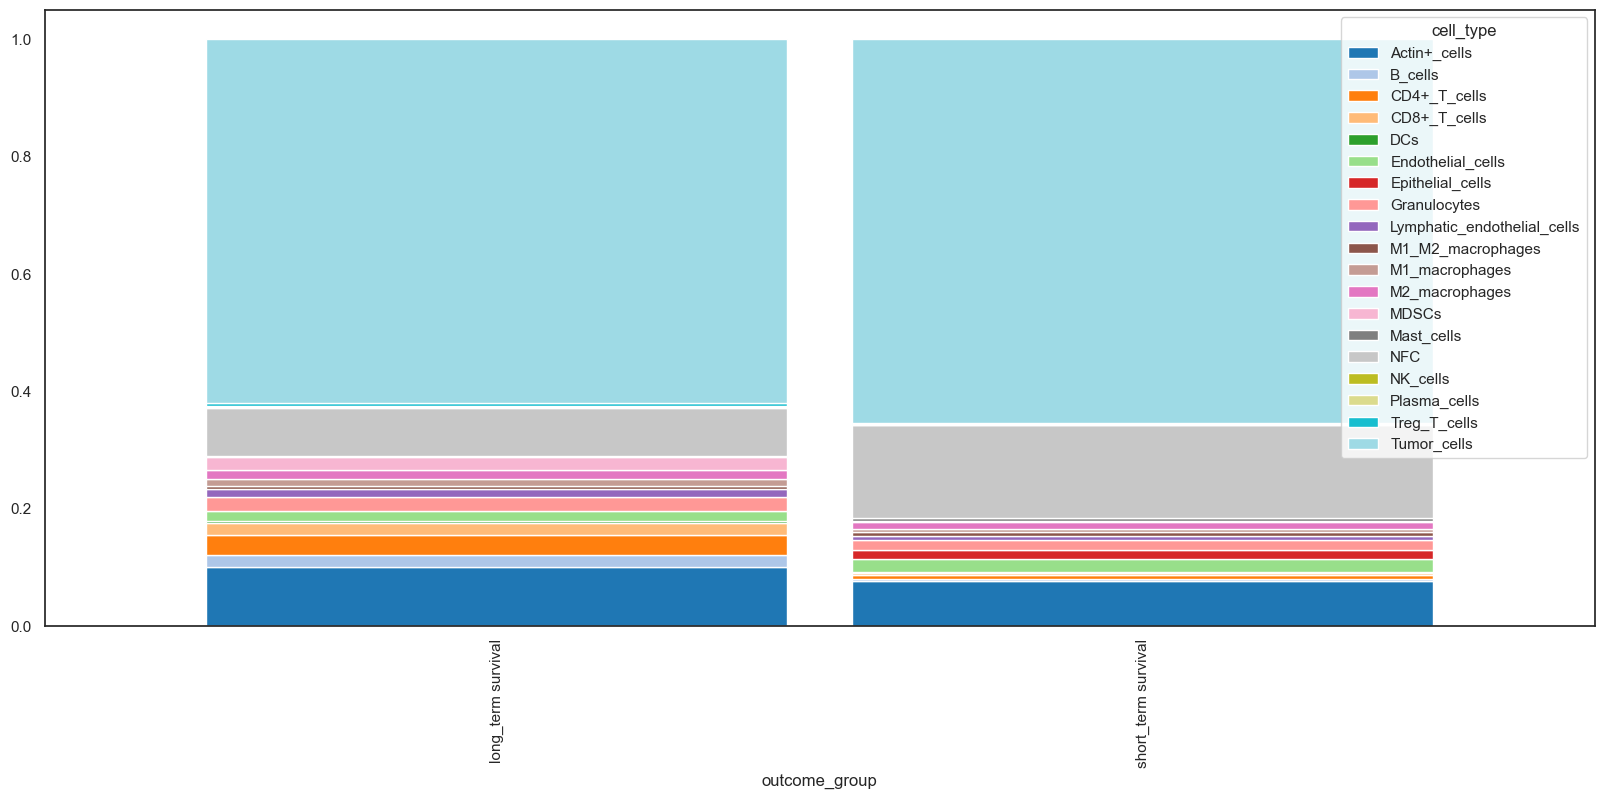

In [115]:
sm.pl.stacked_barplot(adata, x_axis="outcome_group", y_axis="cell_type", method="percent", plot_tool='matplotlib', matplotlib_legend_loc=3, figsize=(20, 8))

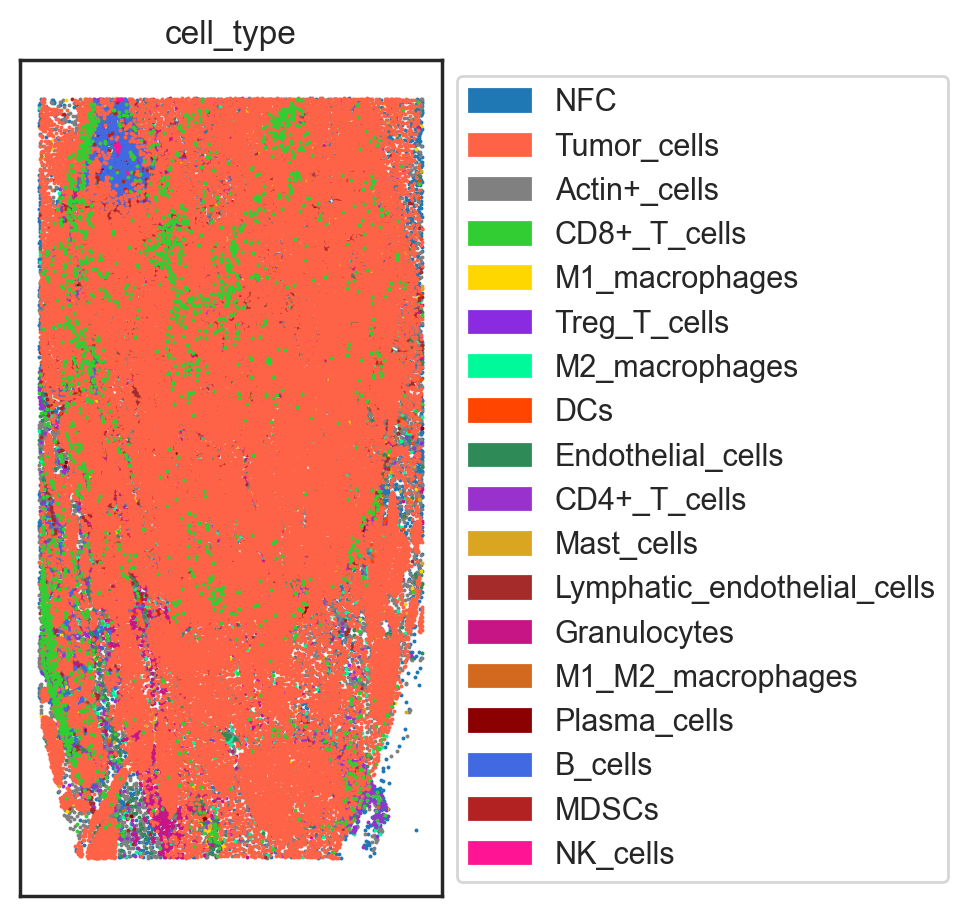

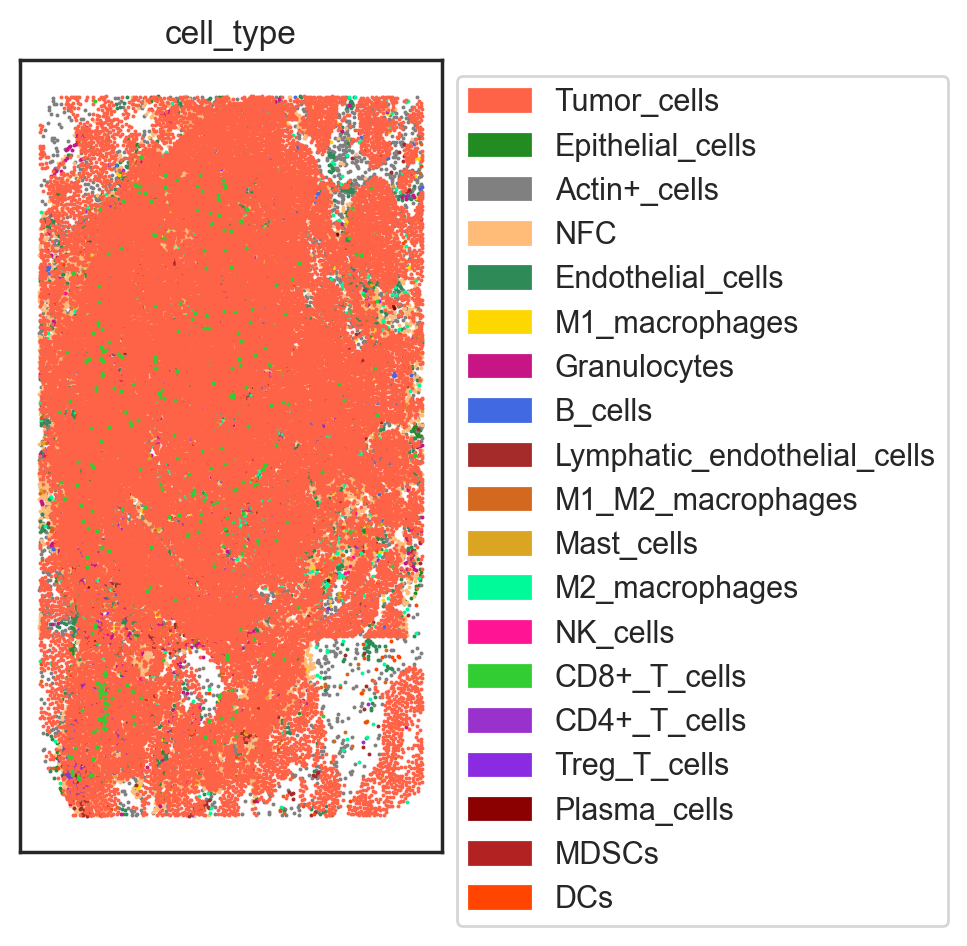

In [70]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)

In [119]:
long_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"]]
short_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"]]


In [121]:
boxplot_data = heatmap_data.melt(var_name='variable', value_name='value', ignore_index=False)
boxplot_data = boxplot_data.filter(like = "CD8+_T_cells-Tumor_cells", axis=0)
boxplot_data["group"] = np.where(boxplot_data["variable"].isin(long_term_zscore), "Long_term", "Short_term")
boxplot_data


,variable,value,group
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI11,-15.521816,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI19,-8.852351,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI8,-28.027726,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI17,-14.573462,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI16,0.350344,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI7,1.055972,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI15,1.813534,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI23,1.628872,Short_term


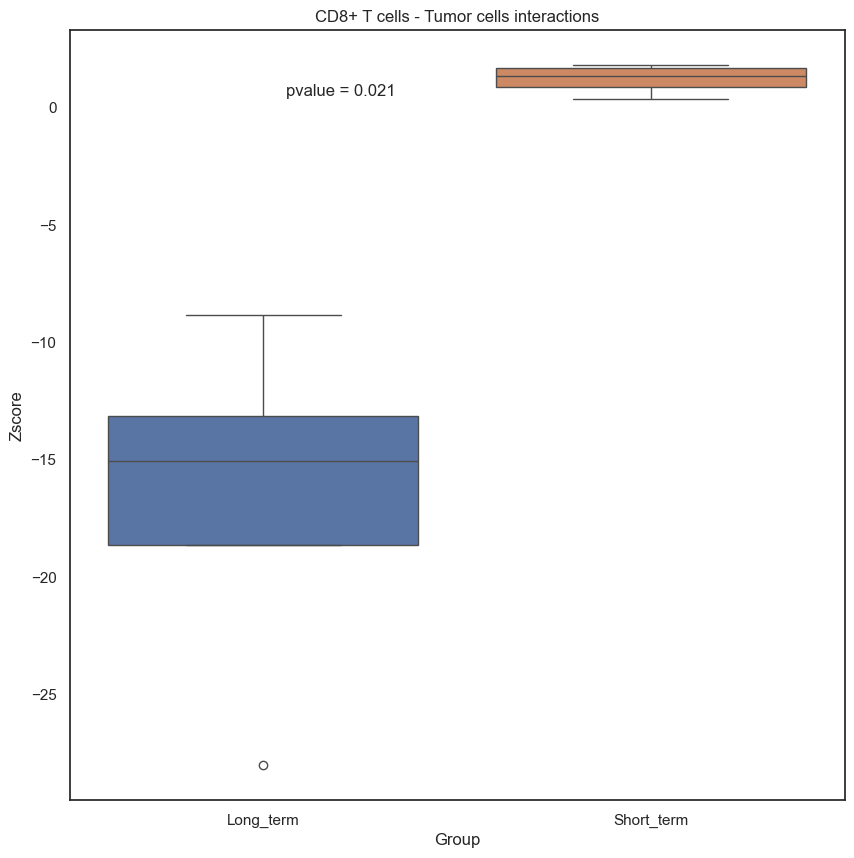

In [136]:
#build a boxplot based on boxplt_data based on matplot
#add the jitter to the boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x='group', y='value', hue='group', data=boxplot_data)
#add title to box plot and labels
plt.title('CD8+ T cells - Tumor cells interactions')
plt.xlabel('Group')
plt.ylabel('Zscore')
#calculate pvalue based on wilcox and add it to the plot
pvalue = sp.stats.ranksums(boxplot_data[boxplot_data["group"] == "Long_term"]["value"], boxplot_data[boxplot_data["group"] == "Short_term"]["value"]).pvalue.round(3)
plt.text(0.2, 0.5, "pvalue = " + str(pvalue), fontsize=12, ha='center')
plt.show()

In [147]:
adata_long = adata[adata.obs["exp_name"].isin(["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"])]
adata_short = adata[adata.obs["exp_name"].isin(["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"])]

In [153]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


In [150]:
adata_long = sm.tl.spatial_distance(adata_long, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')
adata_short = sm.tl.spatial_distance(adata_short, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_distance.py:143: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



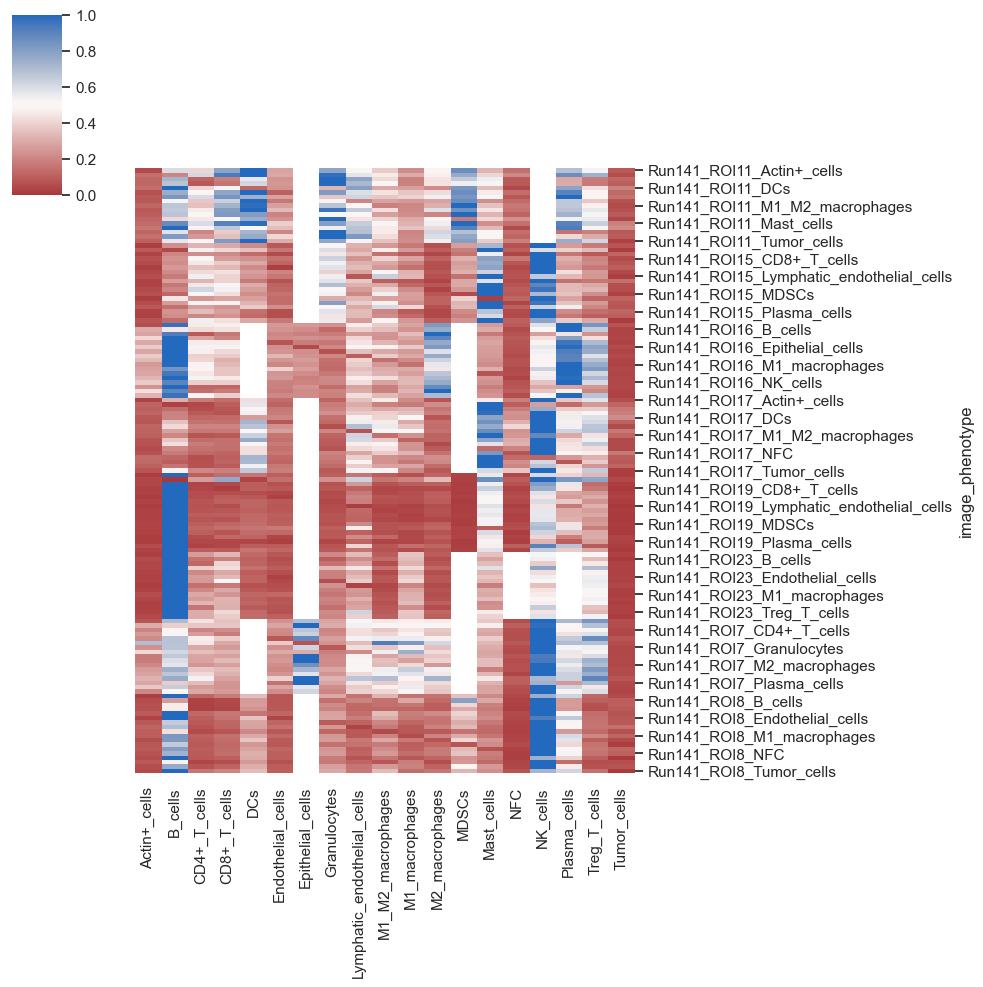

In [157]:
sm.pl.spatial_distance(adata, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance', heatmap_summarize=False)

In [1]:
sm.pl.spatial_distance(adata_long, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')
sm.pl.spatial_distance(adata_short, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')


NameError: name 'sm' is not defined